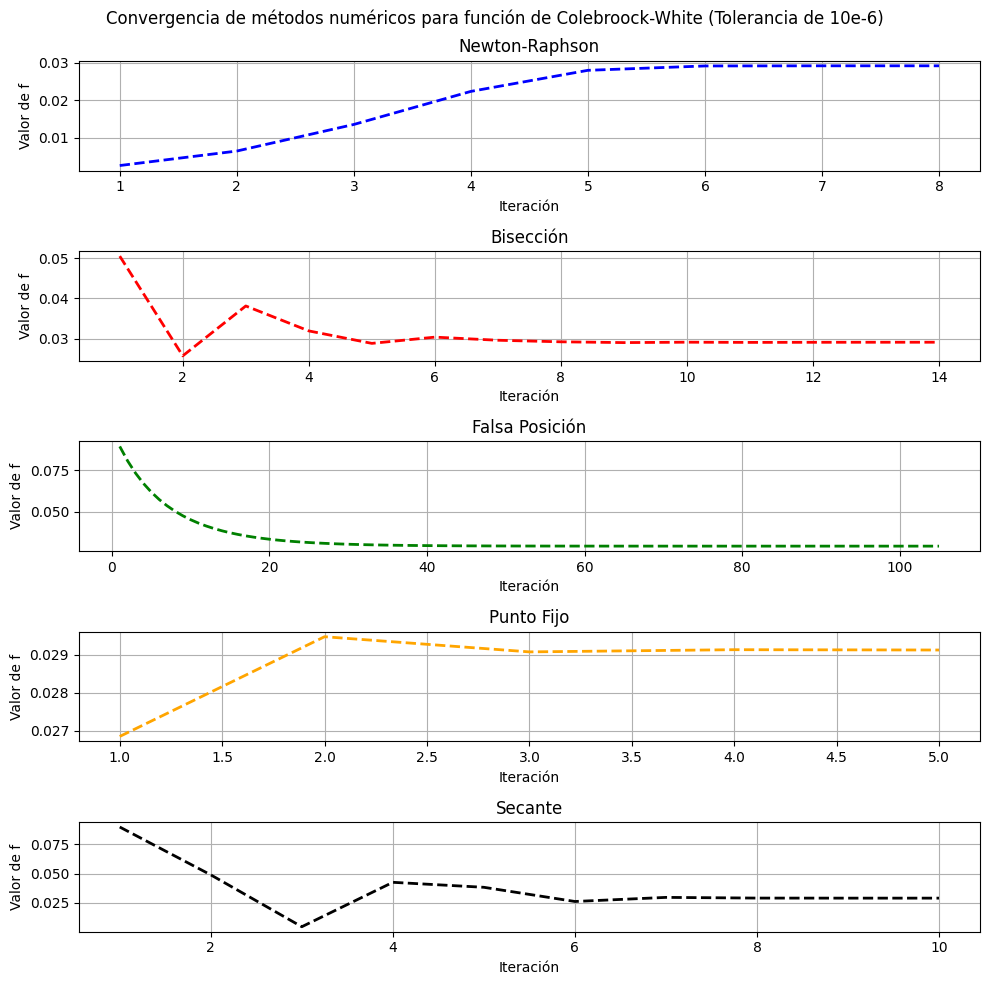

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#Las coeficientes de fricción iniciales y finales dependen del máximo y mínimo obtenible en el diagrama de moody.
#Como inicial se usa lo más cercano a 0, sin ser 0 ya que la ecuación se invalida.
f_inicial = 0.001
f_final = 0.1

#Formulas de coolebrok

def coolebrok(f,r,Re,D):
  #Función original despejado lado izquierdo en 0
  return - 2 * np.log10((r/D)/(3.72) + 2.51/(Re * np.sqrt(f))) - 1 / np.sqrt(f)

def derivada_coolebrok(f,r,Re,D):
  #Función derivada parcial respecto a f
  return (4.03329 * D * np.sqrt(f) + 4.6435 * D + 0.5 * np.sqrt(f) * r * Re) / (9.287 * D * f**(3/2) + f**2 * r * Re)

def g_coolebrok(f,r,Re,D):
  #Función para punto fijo, variable f de lado izquierdo despejada
  return (1/(- 2 * np.log10((r/D)/(3.72) + 2.51/(Re * np.sqrt(f)))))**2

#Métodos númericos
#En cada método se contaran los pasos y se creará un array para graficar los coeficientes de fricción de cada iteración.

def newton_raphson(f_inicial, r, Re, D, tol):
  #En cada iteración, se calcula la corrección h dividiendo el valor actual de la función por su derivada en ese punto. Luego, se actualiza el valor de la variable (f)
  #restando la corrección. Esto se repite hasta que la corrección sea menor que la tolerancia, así obteniendo la raíz .
  pasos = 0
  coordenadas = np.array([])
  h = coolebrok(f_inicial,r,Re,D) / derivada_coolebrok(f_inicial,r,Re,D)
  while abs(h) >= tol:
    pasos += 1
    h = coolebrok(f_inicial,r,Re,D) / derivada_coolebrok(f_inicial,r,Re,D)
    f_inicial = f_inicial - h
    coordenadas = np.append(coordenadas, [pasos, f_inicial])

  return(coordenadas)

def biseccion(f_inicial, f_final, r, Re, D, tol):
    #En cada iteración se divide el intervalo de búsqueda por la mitad. Luego se determina en qué subintervalo se encuentra la raíz y
    #se reduce el espacio de solución de acuerdo a ello, eS por ello que se verifica el signo de la multiplicación de funciones en el f medio y f inicial.
    #Se repite hasta que la longitud del intervalo sea menor que la tolerancia.
    pasos = 0
    coordenadas = np.array([])
    while ((f_final - f_inicial) >= tol):
        pasos += 1
        f_medio = (f_inicial + f_final) / 2

        if (coolebrok(f_medio, r, Re, D) * coolebrok(f_inicial, r, Re, D) < 0):
            f_final = f_medio
        else:
            f_inicial = f_medio

        coordenadas = np.append(coordenadas, [pasos, f_medio])

    return (coordenadas)

def falsa_posicion(f_inicial,f_final, r, Re, D, tol):
  # Similar al método de la bisección, pero en lugar de dividir el intervalo por la mitad, se usa la interpolación lineal para estimar la ubicación de la raíz.
    coordenadas = np.array([])
    pasos = 0
    condicion = True
    while condicion:
        pasos += 1
        f = (f_inicial * coolebrok(f_final,r,Re,D) - f_final * coolebrok(f_inicial,r,Re,D))/ (coolebrok(f_final,r,Re,D) - coolebrok(f_inicial,r,Re,D))

        if coolebrok(f_inicial,r,Re,D) * coolebrok(f,r,Re,D) < 0:
            f_final = f
        else:
            f_inicial = f

        coordenadas = np.append(coordenadas, [pasos, f])
        condicion = abs(coolebrok(f,r,Re,D)) > tol
    return(coordenadas)

def punto_fijo(f_inicial, r, Re, D, tol):
  #El método del punto fijo utiliza la forma x = g(x) para las funciones.
  #Partiendo de una estimación inicial, aplicamos repetidamente la función g(x) para obtener nuevas aproximaciones
    pasos = 0
    coordenadas = np.array([])
    f = g_coolebrok(f_inicial,r,Re,D)
    while abs(f - f_inicial) > tol:
        pasos += 1
        f_inicial = f
        f = g_coolebrok(f_inicial,r,Re,D)
        coordenadas = np.append(coordenadas, [pasos, f])
    return(coordenadas)

def secante(f_inicial,f_final, r, Re, D, tol):
  #el método de la secante utiliza dos estimaciones iniciales (f_inicial y f_final) y aproxima la función mediante una línea recta que pasa por esos dos puntos.
  #La intersección de esta línea recta con el eje x proporciona una nueva estimación de la raíz.
    pasos = 0
    coordenadas = np.array([])
    condicion = True
    while condicion:
        pasos += 1
        f = abs(f_final - (coolebrok(f_final,r,Re,D) * (f_final - f_inicial)) / (coolebrok(f_final,r,Re,D) - coolebrok(f_inicial,r,Re,D)))
        f_inicial = f_final
        f_final = f
        coordenadas = np.append(coordenadas, [pasos, f])
        condicion = abs(coolebrok(f,r,Re,D)) > tol
    return (coordenadas)


def grafico(f_inicial, f_final, r, Re, D, tol):

    nr = newton_raphson(f_inicial, r, Re, D, tol)
    bs = biseccion(f_inicial, f_final, r, Re, D, tol)
    fp = falsa_posicion(f_inicial, f_final, r, Re, D, tol)
    pf = punto_fijo(f_inicial, r, Re, D, tol)
    st = secante(f_inicial,f_final, r, Re, D, tol)

    fig, axes = plt.subplots(5, 1, figsize=(10, 10))

    axes[0].plot(nr[::2], nr[1::2], color='blue', linewidth=2, linestyle='--')
    axes[0].set_title('Newton-Raphson')
    axes[0].set_xlabel('Iteración')
    axes[0].set_ylabel('Valor de f')
    axes[0].grid(True)

    axes[1].plot(bs[::2], bs[1::2], color='red', linewidth=2, linestyle='--')
    axes[1].set_title('Bisección')
    axes[1].set_xlabel('Iteración')
    axes[1].set_ylabel('Valor de f')
    axes[1].grid(True)

    axes[2].plot(fp[::2], fp[1::2], color='green', linewidth=2, linestyle='--')
    axes[2].set_title('Falsa Posición')
    axes[2].set_xlabel('Iteración')
    axes[2].set_ylabel('Valor de f')
    axes[2].grid(True)

    axes[3].plot(pf[::2], pf[1::2], color='Orange', linewidth=2, linestyle='--')
    axes[3].set_title('Punto Fijo')
    axes[3].set_xlabel('Iteración')
    axes[3].set_ylabel('Valor de f')
    axes[3].grid(True)

    axes[4].plot(st[::2], st[1::2], color='Black', linewidth=2, linestyle='--')
    axes[4].set_title('Secante')
    axes[4].set_xlabel('Iteración')
    axes[4].set_ylabel('Valor de f')
    axes[4].grid(True)


    fig.suptitle('Convergencia de métodos numéricos para función de Colebroock-White (Tolerancia de 10e-6)', fontsize=12)
    plt.tight_layout()
    plt.show()


#Datos iniciales
r = 7e-6
D = 0.1
Q = 0.001
Densidad = 998
u = 0.001


V = Q/(np.pi*((D/2)**2))
Re = (V*D*Densidad)/u


#Tolerancia habitual en estos métodos, es la que se usará en todos.
tol = 10e-6

grafico(f_inicial,f_final,r,Re,D, tol)




